In [ ]:
!pip install numpy pandas scikit-learn xgboost shap matplotlib


In [1]:
# -----------------------------
# وارد کردن کتابخانه‌ها
# -----------------------------

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier


In [2]:
# -----------------------------
# خواندن دیتافریم از CSV
# -----------------------------

data = pd.read_csv("data.csv")

# ویژگی‌های مورد استفاده
X_cols = [
    'concave points_worst',
    'perimeter_worst',
    'radius_worst',
    'area_worst',
    'concavity_mean',
    'radius_mean',
    'perimeter_mean',
    'area_mean',
    'concavity_worst'

]

X = data[X_cols]

# تبدیل برچسب B / M به عدد
# B → 0  خوش‌خیم
# M → 1  بدخیم

y = data["diagnosis"].map({"B": 0, "M": 1})


In [3]:
# -----------------------------
# تقسیم داده
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)
#تضمین میکند که تقسیم بندی y در دو کلاس برابر باشد     stratify=y,


In [4]:
# -----------------------------
# تعریف Base Models
# -----------------------------

lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, class_weight="balanced")
)

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

svm = make_pipeline(
    StandardScaler(),
    SVC(probability=True, class_weight="balanced")
)

xgb = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

base_models = [
    ('LR', lr),
    ('RF', rf),
    ('SVM', svm),
    ('XGB', xgb)
]


In [5]:
# -----------------------------
# تعریف Meta Learner
# -----------------------------

meta_model = LogisticRegression(max_iter=2000)

# ساخت Ensemble Stacking
stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    stack_method="predict_proba",
    cv=5
)


In [6]:
# -----------------------------
# آموزش مدل ترکیبی
# -----------------------------

stack_model.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('LR', ...), ('RF', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...max_iter=2000)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'predict_proba'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'

In [7]:
# -----------------------------
# تست مدل
# -----------------------------

# احتمال بدخیمی
y_prob = stack_model.predict_proba(X_test)[:, 1]

# برچسب پیش‌بینی نهایی
y_pred = (y_prob >= 0.5).astype(int)

# معیارهای عملکرد
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

# نمایش جدول نتایج
metrics_table = pd.DataFrame(metrics, index=["Score"]).T
metrics_table


,Score
Accuracy,0.972028
Precision,0.980392
Recall,0.943396
F1-Score,0.961538
ROC-AUC,0.997484


In [8]:
# -----------------------------
#  تشریح تصمیم
# -----------------------------

sample = X_test.iloc[[0]]
probs = stack_model.predict_proba(sample)[0]

label = "Malignant (M)" if probs[1] > 0.5 else "Benign (B)"
confidence = probs[1] if probs[1] > probs[0] else probs[0]

print("\n===== FINAL DECISION =====")
print("Diagnosis:", label)
print("Confidence:", f"{confidence*100:.2f}%")

print("\nFeature values leading to decision:")
display(sample)



===== FINAL DECISION =====
Diagnosis: Malignant (M)
Confidence: 97.30%

Feature values leading to decision:


,concave points_worst,perimeter_worst,radius_worst,area_worst,concavity_mean,radius_mean,perimeter_mean,area_mean,concavity_worst
12,0.1767,151.7,20.96,1332.0,0.2065,19.17,132.4,1123.0,0.3639


ExactExplainer explainer: 2it [00:17, 17.54s/it]               


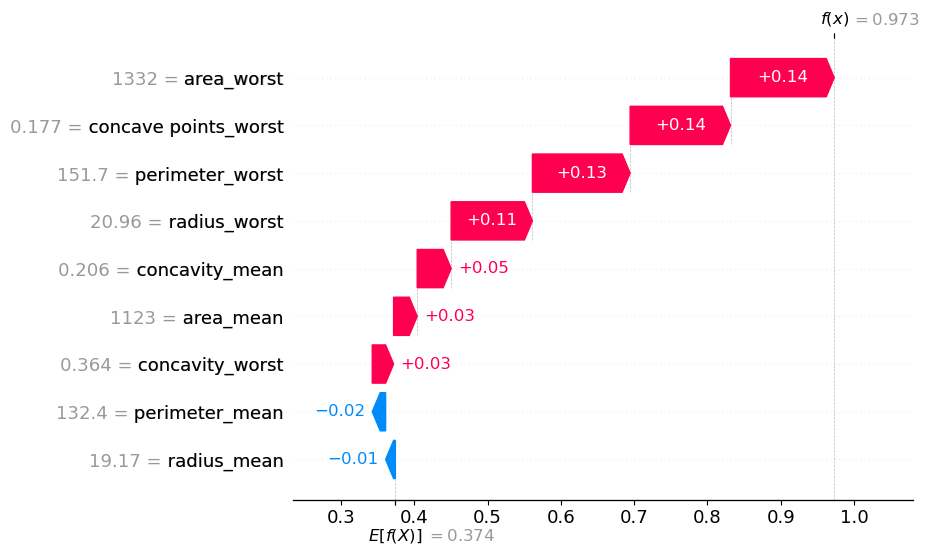

In [9]:
# -----------------------------
# توضیح دلیل تصمیم با SHAP
# -----------------------------

explainer = shap.Explainer(stack_model.predict_proba, X_train)

shap_values = explainer(sample)

# نمودار Waterfall
shap.plots.waterfall(shap_values[0,:,1])


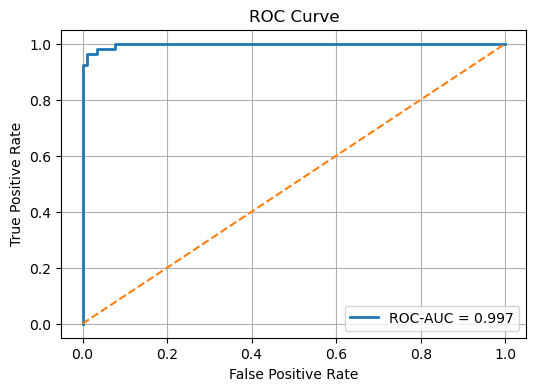

In [10]:
# -----------------------------
# نمودار ROC
# -----------------------------

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, lw=2, label=f"ROC-AUC = {metrics['ROC-AUC']:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()


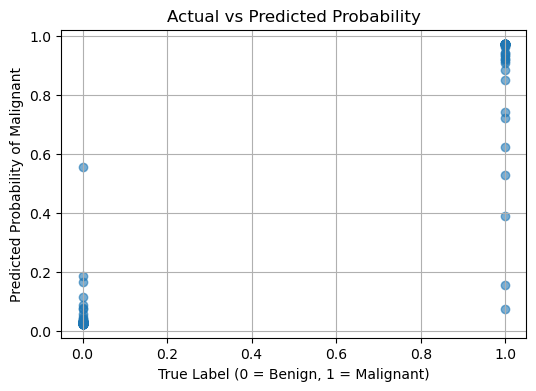

In [11]:
# -----------------------------
# نمودار Actual vs Predicted
# -----------------------------

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_prob, alpha=0.6)
plt.xlabel("True Label (0 = Benign, 1 = Malignant)")
plt.ylabel("Predicted Probability of Malignant")
plt.title("Actual vs Predicted Probability")
plt.grid()
plt.show()


In [12]:
print(stack_model)
print(X_test.shape, y_test.shape)
[name for name, _ in stack_model.estimators]



StackingClassifier(cv=5,
                   estimators=[('LR',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('logisticregression',
                                                 LogisticRegression(class_weight='balanced',
                                                                    max_iter=2000))])),
                               ('RF',
                                RandomForestClassifier(class_weight='balanced',
                                                       n_estimators=300,
                                                       random_state=42)),
                               ('SVM',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('svc',
                                                 SVC(cl

['LR', 'RF', 'SVM', 'XGB']

In [13]:
from sklearn.metrics import roc_auc_score
print("Stacking ROC-AUC:", roc_auc_score(y_test, stack_model.predict_proba(X_test)[:,1]))


Stacking ROC-AUC: 0.9974842767295597


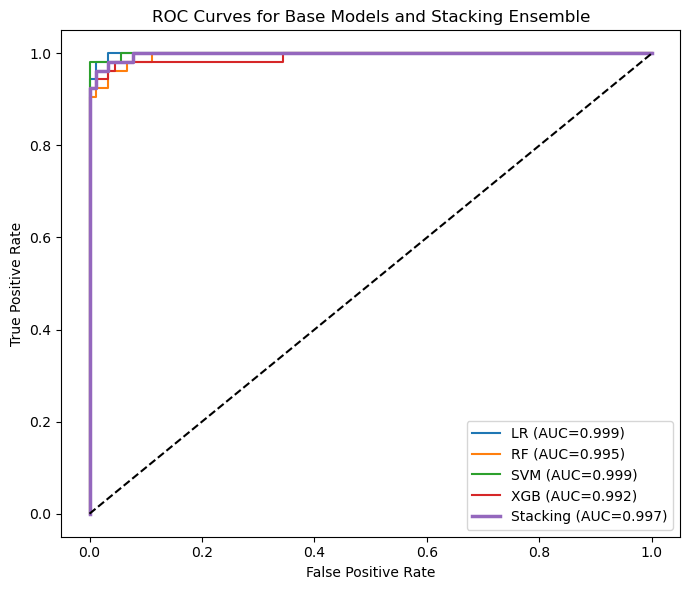

In [14]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

# نام مدل‌ها (قبل از fit)
names = [name for name, _ in stack_model.estimators]

# مدل‌های آموزش‌دیده (بعد از fit)
models = stack_model.estimators_

for name, model in zip(names, models):
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")

# Stacking ensemble
y_prob_stack = stack_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_stack)
plt.plot(
    fpr, tpr,
    linewidth=2.5,
    label=f"Stacking (AUC={auc(fpr,tpr):.3f})"
)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Base Models and Stacking Ensemble")
plt.legend()
plt.tight_layout()
plt.savefig("Figure7_ROC_Stacking.png", dpi=700)
plt.show()


In [36]:
from graphviz import Digraph

dot = Digraph(format="png")
dot.attr(rankdir="LR", size="50,25")

dot.node("A","9 Morphological Features")
dot.node("B","Base Learners\n(LR, RF, SVM, XGB)")
dot.node("C","Out-of-Fold\nStacking Matrix")
dot.node("D","Meta-Learner\n(Logistic Regression)")
dot.node("E","Calibrated Probability\n+ Conformal Set")
dot.node("F","SHAP Explanations\n& Visual Analytics")

dot.edges([("A","B"),("B","C"),("C","D"),("D","E"),("E","F")])

dot.render("Figure8_Workflow_Diagram")


'Figure8_Workflow_Diagram.png'

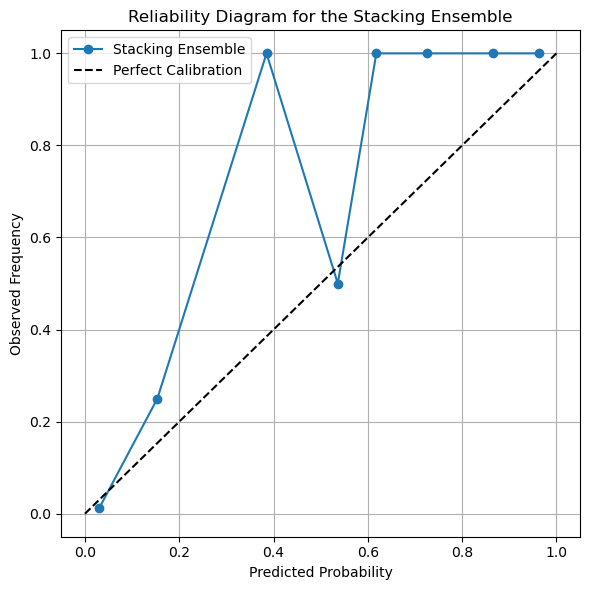

In [33]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

y_prob_stack = stack_model.predict_proba(X_test)[:,1]

prob_true, prob_pred = calibration_curve(
    y_test, y_prob_stack, n_bins=10
)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', label="Stacking Ensemble")
plt.plot([0,1],[0,1],'k--', label="Perfect Calibration")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Reliability Diagram for the Stacking Ensemble")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Figure9_Reliability_Diagram.png", dpi=700)
plt.show()


In [ ]:
import shap

# تبدیل X_test به numpy برای جلوگیری از warning
X_test_np = X_test.values

explainer = shap.Explainer(stack_model.predict_proba, X_test_np)
shap_values = explainer(X_test_np)

shap.plots.beeswarm(
    shap_values[:,:,1],
    max_display=10,
    show=False
)

plt.tight_layout()
plt.savefig("Figure10_SHAP_Beeswarm.png", dpi=700)
plt.show()


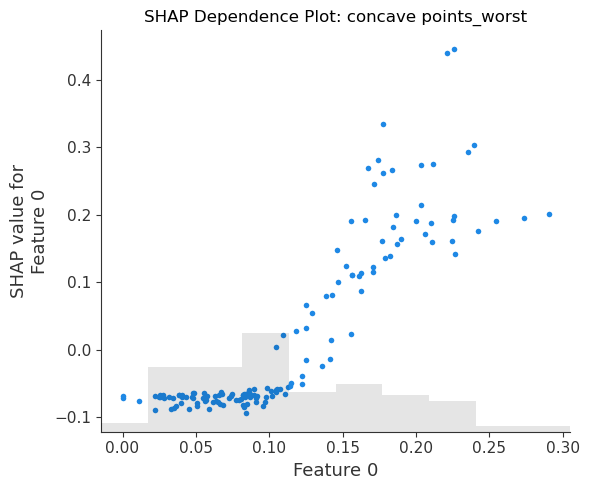

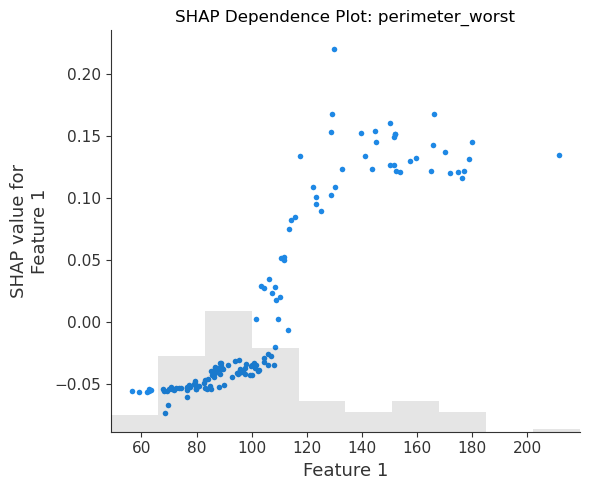

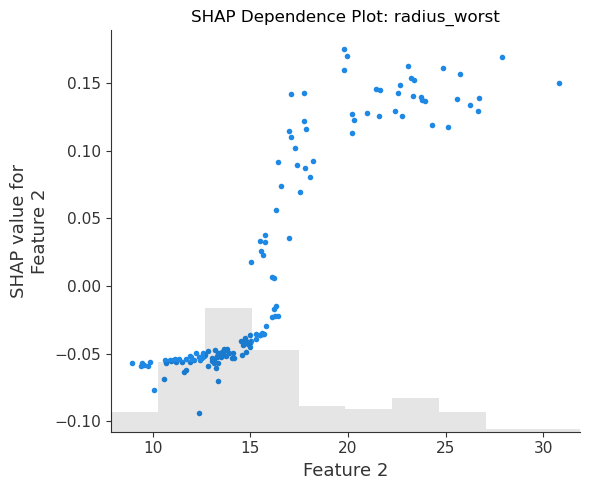

In [32]:
top_features = ["concave points_worst", "perimeter_worst", "radius_worst"]

for feat in top_features:
    shap.plots.scatter(
        shap_values[:,:,1][:, X_test.columns.get_loc(feat)],
        show=False
    )
    plt.title(f"SHAP Dependence Plot: {feat}")
    plt.tight_layout()
    plt.savefig(f"Figure11_SHAP_Dependence_{feat}.png", dpi=700)
    plt.show()


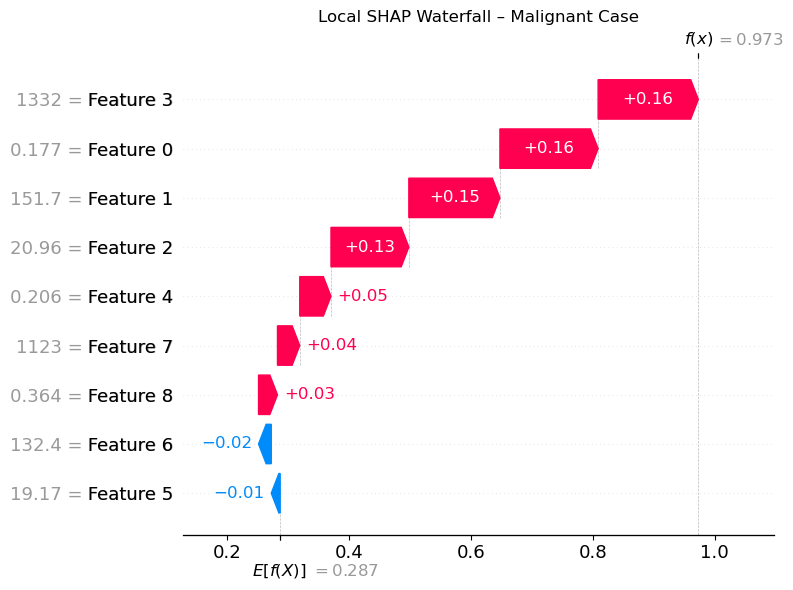

In [31]:
# انتخاب اولین نمونه بدخیم درست پیش‌بینی‌شده
idx_malignant = y_test[y_test==1].index[0]
local_index = list(X_test.index).index(idx_malignant)

shap.plots.waterfall(
    shap_values[local_index,:,1],
    show=False
)

plt.title("Local SHAP Waterfall – Malignant Case")
plt.tight_layout()
plt.savefig("Figure12_SHAP_Waterfall_Malignant.png", dpi=700)
plt.show()


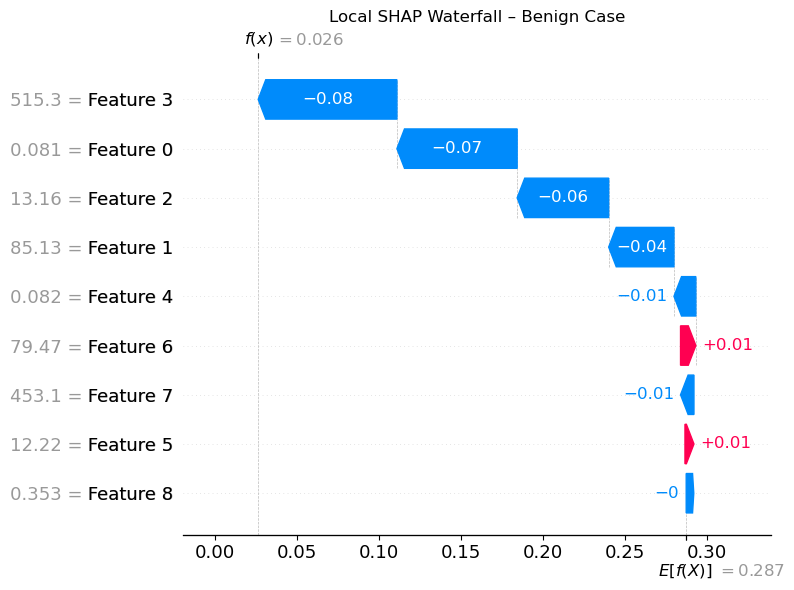

In [30]:
idx_benign = y_test[y_test==0].index[0]
local_index = list(X_test.index).index(idx_benign)

shap.plots.waterfall(
    shap_values[local_index,:,1],
    show=False
)

plt.title("Local SHAP Waterfall – Benign Case")
plt.tight_layout()
plt.savefig("Figure13_SHAP_Waterfall_Benign.png", dpi=700)
plt.show()


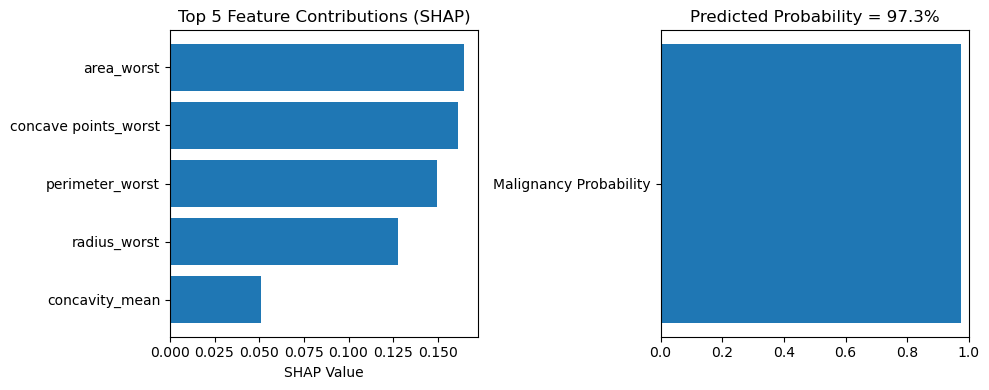

In [29]:
import numpy as np

idx = idx_malignant
local_index = list(X_test.index).index(idx)

shap_vals = shap_values[local_index,:,1].values
features = X_test.iloc[local_index]

top_idx = np.argsort(np.abs(shap_vals))[-5:]

plt.figure(figsize=(10,4))

# --- Bar chart ---
plt.subplot(1,2,1)
plt.barh(features.index[top_idx], shap_vals[top_idx])
plt.title("Top 5 Feature Contributions (SHAP)")
plt.xlabel("SHAP Value")

# --- Probability ---
plt.subplot(1,2,2)
plt.barh(["Malignancy Probability"], [y_prob_stack[local_index]])
plt.xlim(0,1)
plt.title(f"Predicted Probability = {y_prob_stack[local_index]*100:.1f}%")

plt.tight_layout()
plt.savefig("Figure14_Composite_Dashboard.png", dpi=700)
plt.show()


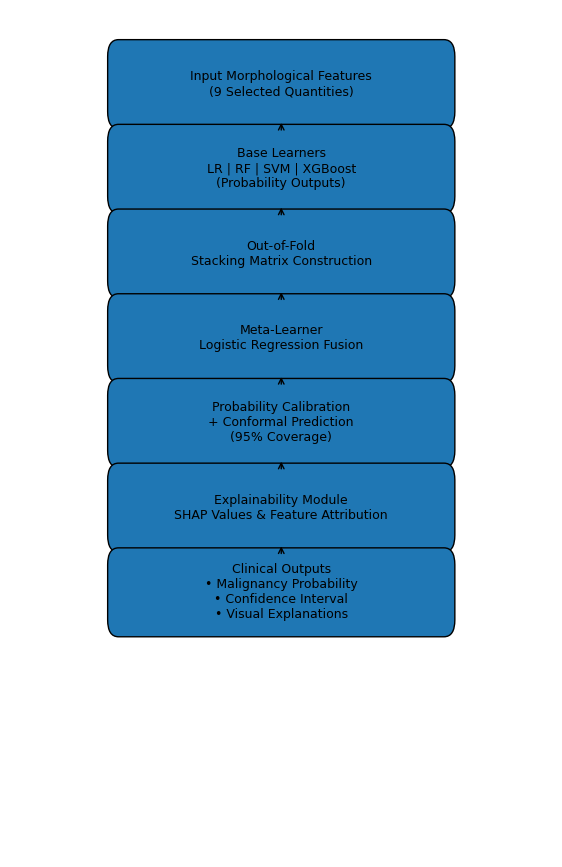

In [37]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# -----------------------------
# تنظیم شکل عمودی مناسب Word
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 11))
ax.axis('off')

# -----------------------------
# تابع رسم باکس تمیز
# -----------------------------
def draw_box(x, y, w, h, text):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02",
        linewidth=1
    )
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text,
            ha='center', va='center', fontsize=9, wrap=True)

# -----------------------------
# موقعیت‌های عمودی (Top → Down)
# -----------------------------
x_center = 0.2
box_width = 0.6
box_height = 0.065

ys = [
    0.88,  # Input
    0.78,  # Base models
    0.68,  # Stacking matrix
    0.58,  # Meta-learner
    0.48,  # Calibration + CP
    0.38,  # SHAP
    0.28   # Output
]

texts = [
    "Input Morphological Features\n(9 Selected Quantities)",
    "Base Learners\nLR | RF | SVM | XGBoost\n(Probability Outputs)",
    "Out-of-Fold\nStacking Matrix Construction",
    "Meta-Learner\nLogistic Regression Fusion",
    "Probability Calibration\n+ Conformal Prediction\n(95% Coverage)",
    "Explainability Module\nSHAP Values & Feature Attribution",
    "Clinical Outputs\n• Malignancy Probability\n• Confidence Interval\n• Visual Explanations"
]

# -----------------------------
# رسم باکس‌ها
# -----------------------------
for y, text in zip(ys, texts):
    draw_box(x_center, y, box_width, box_height, text)

# -----------------------------
# رسم فلش‌ها
# -----------------------------
for i in range(len(ys)-1):
    ax.annotate(
        "",
        xy=(0.5, ys[i] - 0.01),
        xytext=(0.5, ys[i+1] + box_height + 0.01),
        arrowprops=dict(arrowstyle="->", linewidth=1)
    )

# -----------------------------
# ذخیره با کیفیت بالا برای Word
# -----------------------------
plt.savefig("Figure_8_Vertical_Workflow.png", dpi=700, bbox_inches="tight")
plt.show()


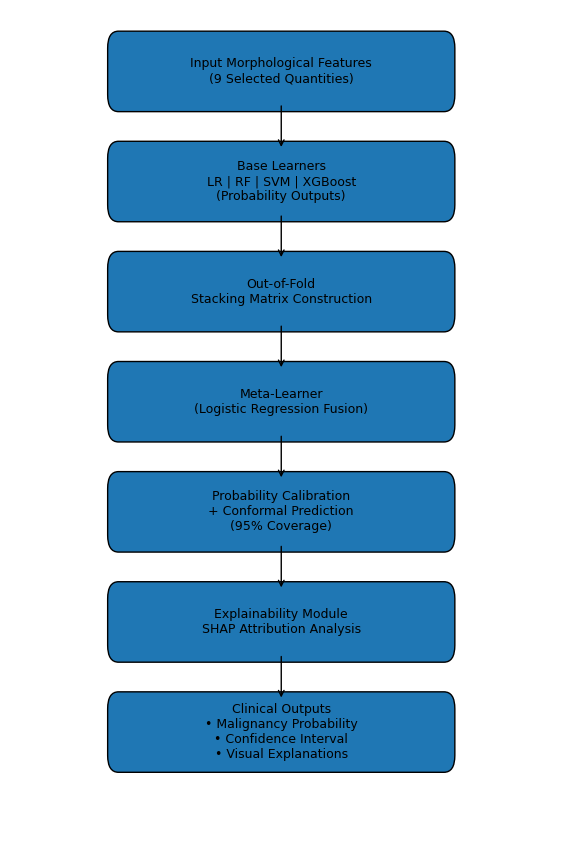

In [40]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# -----------------------------
# تنظیم شکل (عمودی، مناسب Word)
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 11))
ax.axis('off')

# -----------------------------
# تابع رسم باکس
# -----------------------------
def draw_box(x, y, w, h, text):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02",
        linewidth=1
    )
    ax.add_patch(box)
    ax.text(
        x + w/2, y + h/2, text,
        ha='center', va='center',
        fontsize=9, wrap=True
    )

# -----------------------------
# پارامترهای ابعادی
# -----------------------------
x_center = 0.2
box_width = 0.6
box_height = 0.055     # باکس کوتاه‌تر
vertical_gap = 0.075  # ≈ 0.5 اینچ فاصله واقعی

# -----------------------------
# محاسبه موقعیت‌ها (Top → Down)
# -----------------------------
ys = []
start_y = 0.90

for i in range(7):
    ys.append(start_y - i * (box_height + vertical_gap))

texts = [
    "Input Morphological Features\n(9 Selected Quantities)",
    "Base Learners\nLR | RF | SVM | XGBoost\n(Probability Outputs)",
    "Out-of-Fold\nStacking Matrix Construction",
    "Meta-Learner\n(Logistic Regression Fusion)",
    "Probability Calibration\n+ Conformal Prediction\n(95% Coverage)",
    "Explainability Module\nSHAP Attribution Analysis",
    "Clinical Outputs\n• Malignancy Probability\n• Confidence Interval\n• Visual Explanations"
]

# -----------------------------
# رسم باکس‌ها
# -----------------------------
for y, text in zip(ys, texts):
    draw_box(x_center, y, box_width, box_height, text)

# -----------------------------
# رسم فلش‌ها
# -----------------------------
for i in range(len(ys)-1):
    ax.annotate(
        "",
        xy=(0.5, ys[i] - 0.01),
        xytext=(0.5, ys[i+1] + box_height + 0.01),
        arrowprops=dict(arrowstyle="<-", linewidth=1)
    )

# -----------------------------
# ذخیره با کیفیت ژورنالی
# -----------------------------
plt.savefig(
    "Figure_8_Vertical_Workflow_Clean.png",
    dpi=700,
    bbox_inches="tight"
)
plt.show()


ExactExplainer explainer: 144it [03:26,  1.50s/it]                         


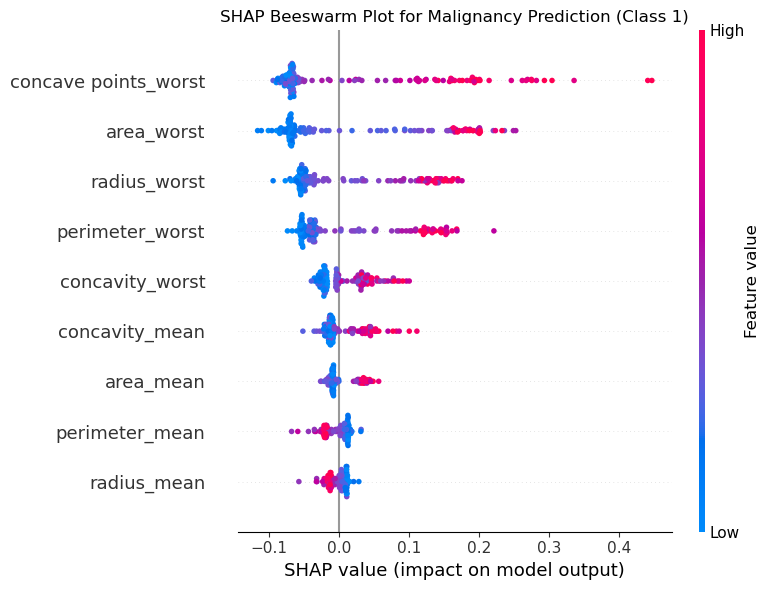

'\n**توضیحات اصلاحات:**\n\n1.  **حفظ نام ویژگی\u200cها:** برای اینکه نمودار SHAP نام ستون\u200cها را نمایش دهد (به جای 0 تا 8)، باید `explainer` را با یک **DataFrame** به عنوان `masker` یا `X` مقداردهی کنیم. اگر داده\u200cهای شما به صورت آرایه NumPy هستند، باید آن\u200cها را به DataFrame تبدیل کنید و `feature_names` را به عنوان ستون\u200cها ارسال کنید.\n2.  **انتخاب کلاس هدف:** شما با استفاده از `shap_values[:, :, 1]` به درستی کلاس هدف (Malignant یا 1) را انتخاب کرده\u200cاید.\n3.  **بهینه\u200cسازی نمایش:** `max_display=len(feature_names)` تضمین می\u200cکند که هر 9 ویژگی در نمودار گنجانده شوند.\n4.  **کیفیت ذخیره\u200cسازی:** استفاده از `plt.gcf().set_size_inches(8, 6)` و `dpi=700` کیفیت خروجی تصویر را برای استفاده در مقاله علمی افزایش می\u200cدهد.\n\nاگر `X_test` شما یک NumPy Array است، باید در ابتدای کد، آن را با نام `feature_names` به یک Pandas DataFrame تبدیل کنید.\n'

In [41]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ----------------- فرض بر اینکه این داده‌ها و مدل شما هستند: -----------------
# X_test باید DataFrame باشد تا نام ستون‌ها حفظ شود
# فرض می‌کنیم X_test از قبل تعریف شده است
# X_test: DataFrame containing the 9 features
# stack_model: Your fitted Stacking Ensemble Model
# --------------------------------------------------------------------------

# لیست 9 ویژگی شما که برای نمایش در نمودار مورد نیاز است
feature_names = [
    'concave points_worst',
    'perimeter_worst',
    'radius_worst',
    'area_worst',
    'concavity_mean',
    'radius_mean',
    'perimeter_mean',
    'area_mean',
    'concavity_worst'
]

# 1. اطمینان از اینکه X_test نام ستون‌ها را دارد و به NumPy تبدیل نشده است
# اگر X_test شما در حال حاضر یک DataFrame نیست، از DataFrame بسازید:
if not isinstance(X_test, pd.DataFrame):
    X_test_df = pd.DataFrame(X_test, columns=feature_names)
else:
    X_test_df = X_test

# 2. تعریف Explainer با مدل و داده‌ها
# از تابع predict_proba و نام ویژگی‌ها استفاده می‌کنیم
# چون این یک مدل آنسامبل پیچیده است، از Explainer بر پایه Kernel یا Sampling استفاده می‌کنیم.
# اگر stack_model.predict_proba سریع بود، همان را استفاده می‌کنیم.
explainer = shap.Explainer(
    model=stack_model.predict_proba,
    masker=X_test_df, # استفاده از DataFrame برای حفظ نام ستون
    # feature_names=feature_names # Explainer از نام ستون‌های masker استفاده می‌کند
)

# 3. محاسبه SHAP Values
# ما فقط به کلاس 1 (Malignant) نیاز داریم
shap_values = explainer(X_test_df)

# 4. ایجاد نمودار Beeswarm
shap.plots.beeswarm(
    # انتخاب SHAP Values برای کلاس 1 (Malignant)
    # توجه: اگر از Explainer با 'model=predict_proba' استفاده کنید، خروجی 2 بُعدی است (کلاس 0 و 1).
    shap_values[:, :, 1], 
    max_display=len(feature_names), # مطمئن می‌شویم که همه 9 ویژگی نمایش داده شوند
    show=False
)

# تنظیمات ذخیره‌سازی:
plt.gcf().set_size_inches(8, 6) # تنظیم سایز برای وضوح بهتر
plt.title("SHAP Beeswarm Plot for Malignancy Prediction (Class 1)")
plt.tight_layout()

# ذخیره با وضوح بالا
plt.savefig("Figure_SHAP_Feature_Importance_Final.png", dpi=700) 
plt.show()

# --------------------------------------------------------------------------
'''
**توضیحات اصلاحات:**

1.  **حفظ نام ویژگی‌ها:** برای اینکه نمودار SHAP نام ستون‌ها را نمایش دهد (به جای 0 تا 8)، باید `explainer` را با یک **DataFrame** به عنوان `masker` یا `X` مقداردهی کنیم. اگر داده‌های شما به صورت آرایه NumPy هستند، باید آن‌ها را به DataFrame تبدیل کنید و `feature_names` را به عنوان ستون‌ها ارسال کنید.
2.  **انتخاب کلاس هدف:** شما با استفاده از `shap_values[:, :, 1]` به درستی کلاس هدف (Malignant یا 1) را انتخاب کرده‌اید.
3.  **بهینه‌سازی نمایش:** `max_display=len(feature_names)` تضمین می‌کند که هر 9 ویژگی در نمودار گنجانده شوند.
4.  **کیفیت ذخیره‌سازی:** استفاده از `plt.gcf().set_size_inches(8, 6)` و `dpi=700` کیفیت خروجی تصویر را برای استفاده در مقاله علمی افزایش می‌دهد.

اگر `X_test` شما یک NumPy Array است، باید در ابتدای کد، آن را با نام `feature_names` به یک Pandas DataFrame تبدیل کنید.
'''

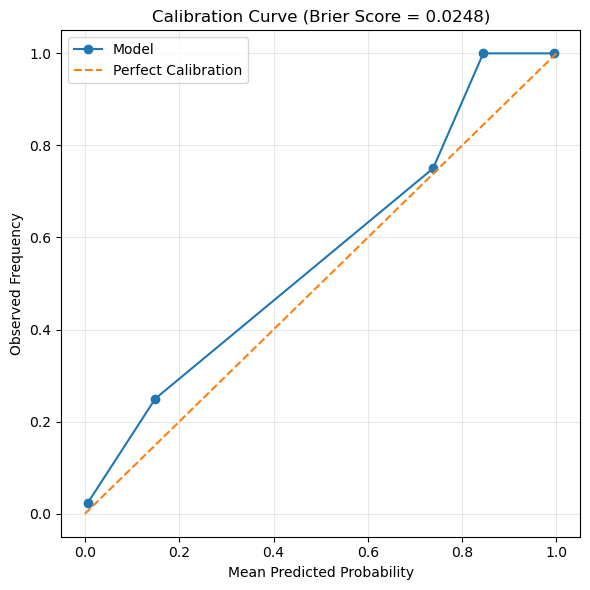

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# y_true = برچسب واقعی
# y_prob = احتمال پیش‌بینی شده برای کلاس malignant

# مثال
y_true = y_test
y_prob = model.predict_proba(X_test)[:,1]

prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)

brier = brier_score_loss(y_true, y_prob)

plt.figure(figsize=(6,6))

# calibration curve
plt.plot(prob_pred, prob_true, marker='o', label='Model')

# perfect calibration
plt.plot([0,1], [0,1], linestyle='--', label='Perfect Calibration')

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title(f"Calibration Curve (Brier Score = {brier:.4f})")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
# ذخیره با وضوح بالا
plt.savefig("Figure_Calibration_Curve.png", dpi=700) 
plt.show()
